# Notebook 3 v2 — Deep Learning Geolocalization (SuperPoint + LightGlue)

| Component | Notebook 2 (Classical) | Notebook 3 (Deep Learning) |
|-----------|----------------------|----------------------------|
| VO features | ORB (handcrafted binary) | **SuperPoint** (learned float) |
| VO matching | BFMatcher + Hamming | **LightGlue** (graph neural net) |
| Satellite tiles | Google Maps Static | **ESRI World Imagery** (free, no key, works in EEA) |
| Satellite features | SIFT + FLANN | **SuperPoint** + **LightGlue** |
| Outlier rejection | Lowe ratio + RANSAC | LightGlue (learned) + RANSAC for H |
| Hardware | CPU-only | CPU or GPU (CUDA / MPS) |

**Changes from v1:**
- Frames extracted from video inside Colab (upload video to Drive, not 14 GB zip)
- Frames saved at JPEG quality 75 and capped at 1920 px wide → ~2 GB on disk
- Satellite tiles from ESRI World Imagery (Google Maps Static blocks satellite type in EEA)
- Drone frames resized to 640×480 before satellite matching (reduces scale mismatch)
- Minimum RANSAC inliers raised from 4 → 15 for satellite anchors
- GPS sanity check rejects anchors more than 2 km from nominal position

---
## Cell 0 — Environment Setup

**Always run this cell first.**

**Colab checklist (do once):**
- Runtime → Change runtime type → **T4 GPU**
- Upload video `IE_Challenge_lat43_521955_lon5_624290.MP4` to `My Drive/capstone-dronomy/`
- Upload your `.env` file to `My Drive/capstone-dronomy/.env`

Frame extraction happens automatically in Cell 0b on first run (~5 min). Subsequent runs reuse extracted frames.

In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    DRIVE_PROJECT = '/content/drive/MyDrive/capstone-dronomy'

    from google.colab import drive
    drive.mount('/content/drive')

    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/cvg/LightGlue.git', 'python-dotenv'],
                   check=True)
    print('Packages installed')

    # -- Load .env from Drive -------------------------------------------------
    from dotenv import dotenv_values
    env_path = f'{DRIVE_PROJECT}/.env'
    if os.path.exists(env_path):
        for k, v in dotenv_values(env_path).items():
            if k not in os.environ:
                os.environ[k] = v
        print('.env loaded from Drive')
    else:
        print(f'No .env at {env_path} — satellite API key unavailable (ESRI needs no key anyway)')

    # -- Path overrides (read by Cells 1 and 2) -------------------------------
    os.environ['DRONOMY_FRAMES_DIR']  = '/content/data/frames_15hz'
    os.environ['DRONOMY_DATA_DIR']    = '/content/data'
    os.environ['DRONOMY_RESULTS_DIR'] = '/content/results/nb3v2'
    os.environ['DRONOMY_VIDEO_PATH']  = f'{DRIVE_PROJECT}/IE_Challenge_lat43_521955_lon5_624290.MP4'

    print('Colab setup complete')
else:
    print('Local environment — skipping Colab setup')

Mounted at /content/drive
Packages installed
.env loaded from Drive
Colab setup complete


---
## Cell 0b — Extract Frames from Video

Reads the video from Drive and extracts frames at 15 Hz directly onto Colab's fast local disk.

- Frames are capped at **1920 px wide** and saved at **JPEG quality 75** (~2 GB total vs 14 GB at 4K/quality 95)
- Skips extraction if frames already exist (safe to re-run)
- On Colab T4: takes ~3–5 minutes

In [2]:
import cv2, os, time
from pathlib import Path

FRAMES_DIR  = Path(os.environ.get('DRONOMY_FRAMES_DIR', '../data/frames_15hz'))
VIDEO_PATH  = Path(os.environ.get('DRONOMY_VIDEO_PATH', '../data/IE_Challenge_lat43_521955_lon5_624290.MP4'))
TARGET_FPS  = 15
MAX_WIDTH   = 1920
JPEG_Q      = 75

existing = list(FRAMES_DIR.glob('*.jpg'))
if existing:
    print(f'Frames already on disk: {len(existing)} files in {FRAMES_DIR}')
elif not VIDEO_PATH.exists():
    print('=' * 60)
    print(f'Video not found at: {VIDEO_PATH}')
    print('Upload the video to your Google Drive at:')
    print(f'  My Drive/capstone-dronomy/IE_Challenge_lat43_521955_lon5_624290.MP4')
    print('Then re-run this cell.')
    print('=' * 60)
else:
    FRAMES_DIR.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    source_fps    = cap.get(cv2.CAP_PROP_FPS)
    total_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s    = total_frames / source_fps if source_fps > 0 else 0
    frame_interval = source_fps / TARGET_FPS

    print(f'Video: {VIDEO_PATH.name}')
    print(f'Source: {source_fps:.1f} fps  |  {total_frames} frames  |  {duration_s:.1f} s')
    print(f'Target: {TARGET_FPS} Hz  |  max width: {MAX_WIDTH} px  |  JPEG quality: {JPEG_Q}')
    print(f'Expected output: ~{int(duration_s * TARGET_FPS)} frames')

    next_sample, saved, frame_idx = 0.0, 0, 0
    t_start = time.perf_counter()

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx >= next_sample:
            h, w = frame.shape[:2]
            if w > MAX_WIDTH:
                frame = cv2.resize(frame, (MAX_WIDTH, int(h * MAX_WIDTH / w)),
                                   interpolation=cv2.INTER_AREA)
            ts_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
            fname = FRAMES_DIR / f'frame_{ts_ms:010d}ms.jpg'
            cv2.imwrite(str(fname), frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q])
            saved += 1
            next_sample += frame_interval
            if saved % 300 == 0:
                elapsed = time.perf_counter() - t_start
                pct = frame_idx / total_frames * 100 if total_frames else 0
                print(f'  {saved} frames  ({pct:.0f}%)  {elapsed:.0f}s elapsed')
        frame_idx += 1

    cap.release()
    elapsed = time.perf_counter() - t_start
    print(f'\nDone: {saved} frames in {elapsed:.1f} s  →  {FRAMES_DIR}')

Video: IE_Challenge_lat43_521955_lon5_624290.MP4
Source: 30.0 fps  |  6853 frames  |  228.7 s
Target: 15 Hz  |  max width: 1920 px  |  JPEG quality: 75
Expected output: ~3429 frames
  300 frames  (9%)  55s elapsed
  600 frames  (17%)  109s elapsed
  900 frames  (26%)  162s elapsed
  1200 frames  (35%)  216s elapsed
  1500 frames  (44%)  271s elapsed
  1800 frames  (52%)  323s elapsed
  2100 frames  (61%)  376s elapsed
  2400 frames  (70%)  431s elapsed
  2700 frames  (79%)  485s elapsed
  3000 frames  (87%)  538s elapsed
  3300 frames  (96%)  591s elapsed

Done: 3430 frames in 613.0 s  →  /content/data/frames_15hz


---
## Cell 1 — Check Frames

In [3]:
import os
from pathlib import Path

FRAMES_DIR = Path(os.environ.get('DRONOMY_FRAMES_DIR', '../data/frames_15hz'))
existing = sorted(FRAMES_DIR.glob('*.jpg'))

if not existing:
    print('No frames found — run Cell 0b first.')
else:
    t0 = int(existing[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(existing[-1].stem.split('_')[1].replace('ms', ''))
    print(f'  {len(existing)} frames  ({(t1-t0)/1000:.1f} s of video)')
    print(f'  Source: {FRAMES_DIR.resolve()}')
    sample = existing[0]
    import cv2
    img = cv2.imread(str(sample))
    print(f'  Frame size: {img.shape[1]}x{img.shape[0]} px')

  3430 frames  (228.6 s of video)
  Source: /content/data/frames_15hz
  Frame size: 1920x1080 px


---
## Cell 2 — Imports & Configuration

In [22]:
import os, io, math, time
import numpy as np
import cv2
import requests
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor
import torch

load_dotenv(dotenv_path=Path('../.env'), override=False)

# -- Credentials (Maps API key kept for reference; ESRI needs no key) ---------
MAPS_API_KEY = os.getenv('MAPS_API_KEY', '')

# -- Location -----------------------------------------------------------------
LAT =  43.521955
LON =  -5.624290

# -- VO parameters ------------------------------------------------------------
DOWNSAMPLE_SIZE = (640, 480)
SAT_MATCH_HZ    = 1.0
SAT_MATCH_EVERY = int(15 / SAT_MATCH_HZ)
SAT_ZOOM        = 18
IMG_SIZE        = 640

# -- SuperPoint / LightGlue parameters ----------------------------------------
MAX_KP_VO  = 1024
MAX_KP_SAT = 4096

# -- Satellite matching quality gates -----------------------------------------
SAT_MATCH_SIZE  = (640, 480)  # resize drone frames before sat matching
MIN_SAT_INLIERS = 8          # min RANSAC inliers to accept an anchor
MAX_ANCHOR_KM   = 2.0         # reject GPS estimates >2 km from nominal

# -- Paths --------------------------------------------------------------------
FRAMES_DIR  = Path(os.environ.get('DRONOMY_FRAMES_DIR',  '../data/frames_15hz'))
DATA_DIR    = Path(os.environ.get('DRONOMY_DATA_DIR',    '../data'))
RESULTS_DIR = Path(os.environ.get('DRONOMY_RESULTS_DIR', '../results/nb3v2'))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

frame_paths = sorted(FRAMES_DIR.glob('*.jpg'))
print(f'Total frames: {len(frame_paths)}')
if frame_paths:
    t0 = int(frame_paths[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(frame_paths[-1].stem.split('_')[1].replace('ms', ''))
    print(f'Duration:     {(t1-t0)/1000:.1f} s')
    print(f'Satellite matches every {SAT_MATCH_EVERY} frames -> ~{len(frame_paths)//SAT_MATCH_EVERY} anchor attempts')
print(f'Results dir:  {RESULTS_DIR.resolve()}')

Total frames: 3430
Duration:     228.6 s
Satellite matches every 15 frames -> ~228 anchor attempts
Results dir:  /content/results/nb3v2


---
## Cell 3 — Deep Learning Models & Utilities

In [5]:
from lightglue import LightGlue, SuperPoint
from lightglue.utils import rbd

torch.set_grad_enabled(False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU:  {props.name}')
    print(f'VRAM: {props.total_memory / 1e9:.1f} GB')

extractor_vo  = SuperPoint(max_num_keypoints=MAX_KP_VO).eval().to(device)
extractor_sat = SuperPoint(max_num_keypoints=MAX_KP_SAT).eval().to(device)
matcher       = LightGlue(features='superpoint',
                           depth_confidence=0.9,
                           width_confidence=0.95).eval().to(device)

def load_img_tensor(path, size=None):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size is not None:
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    t = torch.from_numpy(img).float().permute(2, 0, 1)[None] / 255.0
    return t.to(device)

def arr_to_tensor(arr_rgb):
    t = torch.from_numpy(arr_rgb).float().permute(2, 0, 1)[None] / 255.0
    return t.to(device)

def extract_sp(img_tensor, use_sat=False):
    ext = extractor_sat if use_sat else extractor_vo
    with torch.no_grad():
        return ext.extract(img_tensor)

def match_sp_lg(feats0, feats1):
    with torch.no_grad():
        result = matcher({'image0': feats0, 'image1': feats1})
    f0, f1, res = rbd(feats0), rbd(feats1), rbd(result)
    matches = res['matches']
    if len(matches) == 0:
        return (np.zeros((0, 2), dtype=np.float32),
                np.zeros((0, 2), dtype=np.float32), 0, 0.0)
    pts0   = f0['keypoints'][matches[:, 0]].cpu().numpy()
    pts1   = f1['keypoints'][matches[:, 1]].cpu().numpy()
    scores = res.get('matching_scores', torch.ones(len(matches))).cpu().numpy()
    return pts0, pts1, len(matches), float(scores.mean())

def find_homography(pts0, pts1):
    if len(pts0) < 4:
        return None, 0
    src = pts0.reshape(-1, 1, 2).astype(np.float32)
    dst = pts1.reshape(-1, 1, 2).astype(np.float32)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(mask.sum()) if mask is not None else 0
    return H, inliers

def rotation_from_H(H):
    return math.degrees(math.atan2(H[1, 0], H[0, 0]))

def translation_from_H(H, img_shape):
    h, w = img_shape[:2]
    center = np.float32([[w / 2, h / 2]]).reshape(-1, 1, 2)
    mapped = cv2.perspectiveTransform(center, H).reshape(2)
    return mapped[0] - w / 2, mapped[1] - h / 2

print(f'SuperPoint VO:  max_kp={MAX_KP_VO}')
print(f'SuperPoint sat: max_kp={MAX_KP_SAT}')
print('LightGlue:      depth_conf=0.9  width_conf=0.95')

Device: cuda
GPU:  Tesla T4
VRAM: 15.6 GB
Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 297MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 597MB/s]

SuperPoint VO:  max_kp=1024
SuperPoint sat: max_kp=4096
LightGlue:      depth_conf=0.9  width_conf=0.95


---
## Cell 4 — Visual Odometry: SuperPoint + LightGlue

In [6]:
vo_records      = []
cum_x, cum_y, cum_yaw = 0.0, 0.0, 0.0
timings_ms      = []
match_scores_vo = []

prev_tensor = load_img_tensor(frame_paths[0], size=DOWNSAMPLE_SIZE)
prev_feats  = extract_sp(prev_tensor)
frame_shape = (DOWNSAMPLE_SIZE[1], DOWNSAMPLE_SIZE[0])

vo_records.append({
    'frame_idx': 0, 'path': frame_paths[0],
    'cum_x': 0.0, 'cum_y': 0.0, 'cum_yaw': 0.0,
    'dx': 0.0, 'dy': 0.0, 'dyaw': 0.0,
    'good_matches': 0, 'inliers': 0, 'inlier_ratio': 1.0, 'mean_score': 1.0,
})

total = len(frame_paths) - 1
print(f'Running SuperPoint + LightGlue VO on {total} frame pairs...')
t_start = time.perf_counter()

for i in range(total):
    t0 = time.perf_counter()

    curr_tensor = load_img_tensor(frame_paths[i + 1], size=DOWNSAMPLE_SIZE)
    curr_feats  = extract_sp(curr_tensor)
    pts0, pts1, n_matches, score = match_sp_lg(prev_feats, curr_feats)
    H, inliers  = find_homography(pts0, pts1)

    if H is not None:
        dx, dy       = translation_from_H(H, frame_shape)
        dyaw         = rotation_from_H(H)
        inlier_ratio = inliers / n_matches if n_matches > 0 else 0.0
    else:
        dx = dy = dyaw = 0.0
        inlier_ratio = 0.0

    cum_x   += dx
    cum_y   += dy
    cum_yaw += dyaw

    vo_records.append({
        'frame_idx': i + 1, 'path': frame_paths[i + 1],
        'cum_x': cum_x, 'cum_y': cum_y, 'cum_yaw': cum_yaw,
        'dx': dx, 'dy': dy, 'dyaw': dyaw,
        'good_matches': n_matches, 'inliers': inliers,
        'inlier_ratio': inlier_ratio, 'mean_score': score,
    })

    prev_tensor = curr_tensor
    prev_feats  = curr_feats
    timings_ms.append((time.perf_counter() - t0) * 1000)
    match_scores_vo.append(score)

    if (i + 1) % 500 == 0:
        elapsed = time.perf_counter() - t_start
        fps = (i + 1) / elapsed
        print(f'  {i+1}/{total}  |  mean {np.mean(timings_ms[-500:]):.1f} ms/frame  |  {fps:.1f} fps')

total_s   = time.perf_counter() - t_start
budget_ms = 1000 / 15
live_str  = 'live-ready' if np.mean(timings_ms) < budget_ms else 'exceeds budget'
print(f'\nDone -- {total} frames in {total_s:.1f} s')
print(f'Mean per-frame time:       {np.mean(timings_ms):.1f} ms ({live_str} at 15 Hz)')
print(f'Mean LightGlue confidence: {np.mean(match_scores_vo):.3f}')
if device.type == 'cuda':
    torch.cuda.empty_cache()

Running SuperPoint + LightGlue VO on 3429 frame pairs...
  500/3429  |  mean 76.7 ms/frame  |  13.0 fps
  1000/3429  |  mean 75.3 ms/frame  |  13.2 fps
  1500/3429  |  mean 75.3 ms/frame  |  13.2 fps
  2000/3429  |  mean 75.3 ms/frame  |  13.2 fps
  2500/3429  |  mean 74.3 ms/frame  |  13.3 fps
  3000/3429  |  mean 77.0 ms/frame  |  13.2 fps

Done -- 3429 frames in 260.0 s
Mean per-frame time:       75.8 ms (exceeds budget at 15 Hz)
Mean LightGlue confidence: 1.000


---
## Cell 5 — VO Quality Metrics

Mean inlier ratio:     0.997
Median inlier ratio:   0.998
Failed pairs (IR<0.2): 0 / 3429
Mean good matches:     695
Mean inliers:          693
Mean LG confidence:    1.000


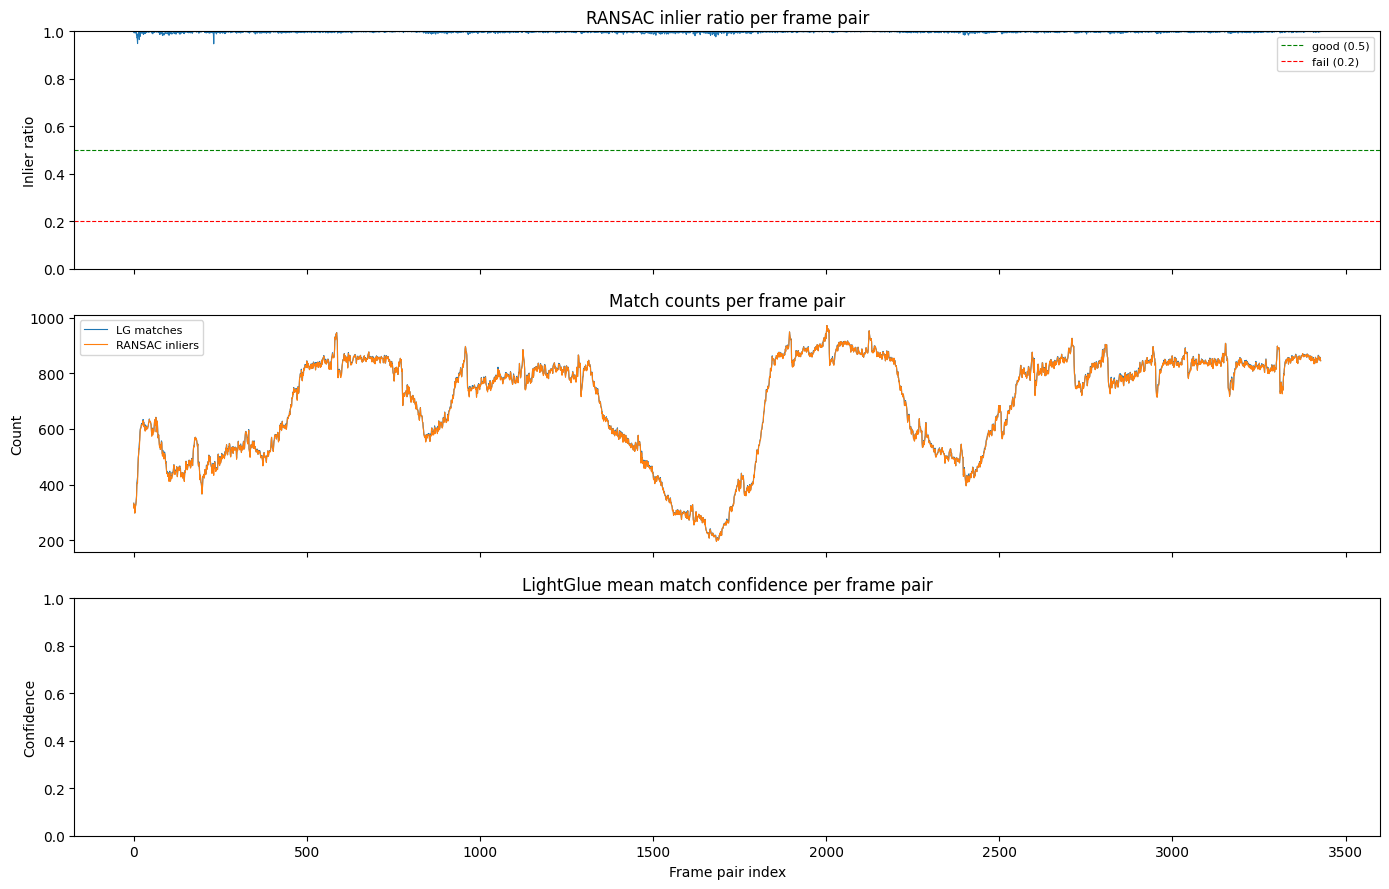

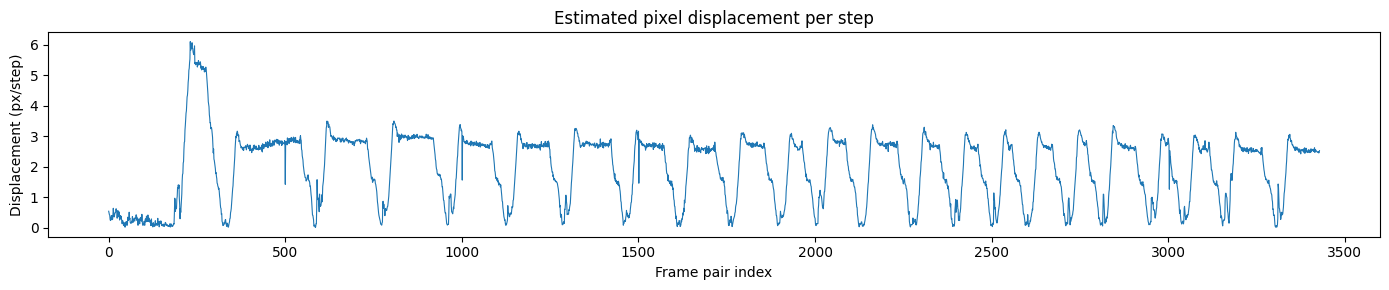

Mean displacement: 1.9 px/step  |  Max: 6.1 px  |  Std: 1.1 px


In [7]:
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
good_counts   = [r['good_matches'] for r in vo_records[1:]]
inlier_counts = [r['inliers']      for r in vo_records[1:]]
scores_list   = [r['mean_score']   for r in vo_records[1:]]

print(f'Mean inlier ratio:     {np.mean(inlier_ratios):.3f}')
print(f'Median inlier ratio:   {np.median(inlier_ratios):.3f}')
print(f'Failed pairs (IR<0.2): {sum(r < 0.2 for r in inlier_ratios)} / {len(inlier_ratios)}')
print(f'Mean good matches:     {np.mean(good_counts):.0f}')
print(f'Mean inliers:          {np.mean(inlier_counts):.0f}')
print(f'Mean LG confidence:    {np.mean(scores_list):.3f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(inlier_ratios, linewidth=0.8)
axes[0].axhline(0.5, color='g', linestyle='--', linewidth=0.8, label='good (0.5)')
axes[0].axhline(0.2, color='r', linestyle='--', linewidth=0.8, label='fail (0.2)')
axes[0].set_ylabel('Inlier ratio')
axes[0].set_title('RANSAC inlier ratio per frame pair')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

axes[1].plot(good_counts,   linewidth=0.8, label='LG matches')
axes[1].plot(inlier_counts, linewidth=0.8, label='RANSAC inliers')
axes[1].set_ylabel('Count')
axes[1].set_title('Match counts per frame pair')
axes[1].legend(fontsize=8)

axes[2].plot(scores_list, linewidth=0.8, color='purple')
axes[2].set_ylabel('Confidence')
axes[2].set_xlabel('Frame pair index')
axes[2].set_title('LightGlue mean match confidence per frame pair')
axes[2].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'vo_inlier_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

displacements = [math.hypot(r['dx'], r['dy']) for r in vo_records[1:]]
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(displacements, linewidth=0.8)
ax2.set_ylabel('Displacement (px/step)')
ax2.set_xlabel('Frame pair index')
ax2.set_title('Estimated pixel displacement per step')
plt.tight_layout()
fig2.savefig(RESULTS_DIR / 'vo_displacement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean displacement: {np.mean(displacements):.1f} px/step  |  '
      f'Max: {np.max(displacements):.1f} px  |  Std: {np.std(displacements):.1f} px')

---
## Cell 6 — Satellite Tile: ESRI World Imagery

Uses **ESRI World Imagery** instead of Google Maps Static API.
- Free, no API key required
- Works in the EU / EEA (Google Maps blocks satellite type for EEA accounts)
- Comparable resolution (~0.3 m/px at zoom 19)

Fetching satellite tile from ESRI World Imagery...
Tile fetched and cached.
Satellite tile ready: 640x640 px
Coverage: 139 m x 139 m at zoom 19
SuperPoint keypoints in satellite tile: 1409


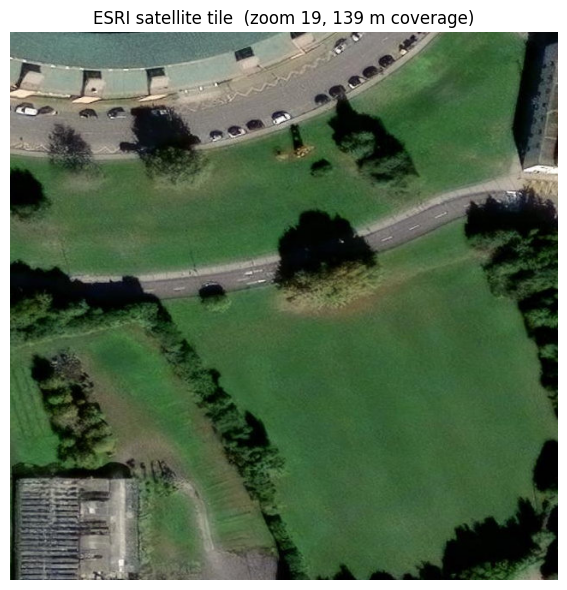

In [8]:
def meters_per_pixel(lat_deg, zoom):
    return 156543.03392 * math.cos(math.radians(lat_deg)) / (2 ** zoom)

def tile_bbox(lat, lon, zoom, size=IMG_SIZE):
    mpp   = meters_per_pixel(lat, zoom)
    half  = mpp * size / 2
    dlat  = half / 111320
    dlon  = half / (111320 * math.cos(math.radians(lat)))
    return lat - dlat, lat + dlat, lon - dlon, lon + dlon

def pixel_to_gps(px, py, img_w, img_h, lat_min, lat_max, lon_min, lon_max):
    lat = lat_max - (py / img_h) * (lat_max - lat_min)
    lon = lon_min + (px / img_w) * (lon_max - lon_min)
    return lat, lon

def fetch_esri_tile(lat, lon, size, zoom):
    """ESRI World Imagery aerial tile — free, no API key, EEA-safe."""
    lat_min, lat_max, lon_min, lon_max = tile_bbox(lat, lon, zoom, size)
    url = (
        'https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/export'
        f'?bbox={lon_min},{lat_min},{lon_max},{lat_max}'
        f'&bboxSR=4326&size={size},{size}&imageSR=4326&format=jpg&transparent=false&f=image'
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return np.array(Image.open(io.BytesIO(resp.content)).convert('RGB'))

sat_tile  = None
sat_gray  = None
sat_feats = None
bbox_sat  = None
mpp_sat   = None

sat_path = DATA_DIR / f'satellite_esri_z{SAT_ZOOM}.png'

if sat_path.exists():
    print('Loading cached ESRI satellite tile...')
    sat_tile = np.array(Image.open(sat_path).convert('RGB'))
else:
    print('Fetching satellite tile from ESRI World Imagery...')
    try:
        sat_tile = fetch_esri_tile(LAT, LON, IMG_SIZE, SAT_ZOOM)
        Image.fromarray(sat_tile).save(sat_path)
        print('Tile fetched and cached.')
    except requests.exceptions.RequestException as e:
        print(f'ESRI fetch failed: {e}')

if sat_tile is not None:
    sat_gray  = cv2.cvtColor(sat_tile, cv2.COLOR_RGB2GRAY)
    bbox_sat  = tile_bbox(LAT, LON, SAT_ZOOM)
    mpp_sat   = meters_per_pixel(LAT, SAT_ZOOM)
    sat_tensor = arr_to_tensor(sat_tile)
    sat_feats  = extract_sp(sat_tensor, use_sat=True)
    sh, sw     = sat_gray.shape
    n_sat_kp   = sat_feats['keypoints'].shape[1]
    print(f'Satellite tile ready: {sw}x{sh} px')
    print(f'Coverage: {mpp_sat*IMG_SIZE:.0f} m x {mpp_sat*IMG_SIZE:.0f} m at zoom {SAT_ZOOM}')
    print(f'SuperPoint keypoints in satellite tile: {n_sat_kp}')

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(sat_tile)
    ax.set_title(f'ESRI satellite tile  (zoom {SAT_ZOOM}, {mpp_sat*IMG_SIZE:.0f} m coverage)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## Cell 7 — Satellite Anchors: GPS Fixes at 1 Hz

Key improvements over v1:
- Drone frames resized to `SAT_MATCH_SIZE` (640×480) before matching — reduces scale mismatch with the satellite tile
- `MIN_SAT_INLIERS = 15` — raises bar for accepting an anchor (4 is the minimum for homography, too permissive)
- GPS sanity check — rejects estimates more than `MAX_ANCHOR_KM` from the nominal position

In [23]:
anchors = []

if sat_feats is None:
    print('No satellite tile -- skipping anchors')
else:
    anchor_frame_indices = [
        i for i in range(len(vo_records)) if vo_records[i]['frame_idx'] % SAT_MATCH_EVERY == 0
    ]
    print(f'Running SuperPoint+LightGlue satellite match on {len(anchor_frame_indices)} frames...')
    print(f'  Frame resize: {SAT_MATCH_SIZE}  |  min inliers: {MIN_SAT_INLIERS}  |  max dist: {MAX_ANCHOR_KM} km')

    def sat_match_dl(vo_rec):
        # Resize drone frame to reduce scale mismatch with satellite tile
        img_t       = load_img_tensor(vo_rec['path'], size=SAT_MATCH_SIZE)
        frame_feats = extract_sp(img_t, use_sat=True)
        pts_frame, pts_sat, n_matches, score = match_sp_lg(frame_feats, sat_feats)
        H, inliers  = find_homography(pts_frame, pts_sat)
        if H is None or inliers < MIN_SAT_INLIERS:
            return None
        dh = img_t.shape[2]
        dw = img_t.shape[3]
        center = np.float32([[dw / 2, dh / 2]]).reshape(-1, 1, 2)
        mapped = cv2.perspectiveTransform(center, H).reshape(2)
        est_lat, est_lon = pixel_to_gps(mapped[0], mapped[1], sw, sh, *bbox_sat)
        # GPS sanity check
        dlat_m = (est_lat - LAT) * 111320
        dlon_m = (est_lon - LON) * 111320 * math.cos(math.radians(LAT))
        dist_m = math.hypot(dlat_m, dlon_m)
        if dist_m > MAX_ANCHOR_KM * 1000:
            return None
        return {
            'frame_idx':      vo_rec['frame_idx'],
            'est_lat':        est_lat,
            'est_lon':        est_lon,
            'good_matches':   n_matches,
            'inliers':        inliers,
            'mean_score':     score,
            'vo_cum_x':       vo_rec['cum_x'],
            'vo_cum_y':       vo_rec['cum_y'],
            'dist_nominal_m': dist_m,
        }

    t_sat = time.perf_counter()
    with ThreadPoolExecutor(max_workers=1) as pool:
        futures = {pool.submit(sat_match_dl, vo_records[ai]): ai
                   for ai in anchor_frame_indices}
        for fut, ai in futures.items():
            result = fut.result()
            if result is not None:
                result['vo_idx'] = ai
                anchors.append(result)

    sat_time = time.perf_counter() - t_sat
    anchors.sort(key=lambda a: a['frame_idx'])
    print(f'Successful anchors: {len(anchors)} / {len(anchor_frame_indices)}  '
          f'({sat_time:.1f} s total, {sat_time/max(1,len(anchor_frame_indices))*1000:.0f} ms/anchor)')
    for a in anchors:
        print(f"  frame {a['frame_idx']:>5}: lat {a['est_lat']:.6f}  "
              f"lon {a['est_lon']:.6f}  inliers {a['inliers']}  "
              f"score {a['mean_score']:.3f}  dist_nominal {a['dist_nominal_m']:.0f} m")

Running SuperPoint+LightGlue satellite match on 229 frames...
  Frame resize: (640, 480)  |  min inliers: 8  |  max dist: 2.0 km
Successful anchors: 4 / 229  (22.1 s total, 96 ms/anchor)
  frame   495: lat 43.521427  lon -5.624777  inliers 9  score 1.000  dist_nominal 71 m
  frame  2175: lat 43.521572  lon -5.624620  inliers 8  score 1.000  dist_nominal 50 m
  frame  2700: lat 43.521664  lon -5.624595  inliers 8  score 1.000  dist_nominal 41 m
  frame  2715: lat 43.521683  lon -5.624669  inliers 8  score 1.000  dist_nominal 43 m


---
## Cell 8 — Scale Calibration: Pixels → Meters

In [24]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlam  = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

scale_m_per_px = None

if len(anchors) >= 2:
    scales = []
    for i in range(len(anchors) - 1):
        a0, a1 = anchors[i], anchors[i+1]
        gps_dist_m = haversine_m(a0['est_lat'], a0['est_lon'],
                                  a1['est_lat'], a1['est_lon'])
        vo_dist_px = math.hypot(a1['vo_cum_x'] - a0['vo_cum_x'],
                                 a1['vo_cum_y'] - a0['vo_cum_y'])
        if vo_dist_px > 1:
            scales.append(gps_dist_m / vo_dist_px)
    if scales:
        scale_m_per_px = float(np.median(scales))
        print(f'Scale estimates (m/px): {[f"{s:.4f}" for s in scales]}')
        print(f'Median scale: {scale_m_per_px:.4f} m/px')
        print(f'Implied drone footprint width: ~{scale_m_per_px * DOWNSAMPLE_SIZE[0]:.0f} m')
elif mpp_sat is not None:
    scale_m_per_px = mpp_sat
    print(f'Only {len(anchors)} anchor(s) -- using satellite m/px as fallback: '
          f'{scale_m_per_px:.4f} m/px')
else:
    print('Cannot estimate scale -- no satellite anchors available')
    scale_m_per_px = 1.0

Scale estimates (m/px): ['0.0059', '0.0112', '1.2879']
Median scale: 0.0112 m/px
Implied drone footprint width: ~7 m


---
## Cell 9 — Drift Evaluation

In [25]:
drift_records = []

if len(anchors) < 2:
    print('Need >= 2 anchors to evaluate drift')
else:
    a0 = anchors[0]
    origin_lat, origin_lon   = a0['est_lat'], a0['est_lon']
    origin_vo_x, origin_vo_y = a0['vo_cum_x'], a0['vo_cum_y']

    print(f'{"Frame":>6} {"GPS lat":>12} {"GPS lon":>12} '
          f'{"VO East (m)":>12} {"VO North (m)":>12} {"Drift (m)":>10} {"Time (s)":>9}')
    print('-' * 80)

    for a in anchors[1:]:
        gps_north = (a['est_lat'] - origin_lat) * 111320
        gps_east  = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))

        vo_dx_m  = (a['vo_cum_x'] - origin_vo_x) * scale_m_per_px
        vo_dy_m  = (a['vo_cum_y'] - origin_vo_y) * scale_m_per_px
        vo_east  =  vo_dx_m
        vo_north = -vo_dy_m

        drift_m = math.hypot(gps_east - vo_east, gps_north - vo_north)
        time_s  = a['frame_idx'] / 15.0

        drift_records.append({'time_s': time_s, 'drift_m': drift_m,
                               'gps_east': gps_east, 'gps_north': gps_north,
                               'vo_east': vo_east, 'vo_north': vo_north})
        print(f"{a['frame_idx']:>6} {a['est_lat']:>12.6f} {a['est_lon']:>12.6f} "
              f"{vo_east:>12.1f} {vo_north:>12.1f} {drift_m:>10.1f} {time_s:>9.1f}")

    if drift_records:
        max_t = drift_records[-1]['time_s']
        max_d = drift_records[-1]['drift_m']
        if max_t > 0:
            print(f'\nDrift after {max_t:.1f}s: {max_d:.1f} m  ({max_d/max_t:.2f} m/s drift rate)')

 Frame      GPS lat      GPS lon  VO East (m) VO North (m)  Drift (m)  Time (s)
--------------------------------------------------------------------------------
  2175    43.521572    -5.624620         -0.4        -38.7       56.4     145.0
  2700    43.521664    -5.624595         -0.5        -49.1       76.9     180.0
  2715    43.521683    -5.624669         -0.5        -49.1       78.1     181.0

Drift after 181.0s: 78.1 m  (0.43 m/s drift rate)


---
## Cell 10 — Trajectory Plot

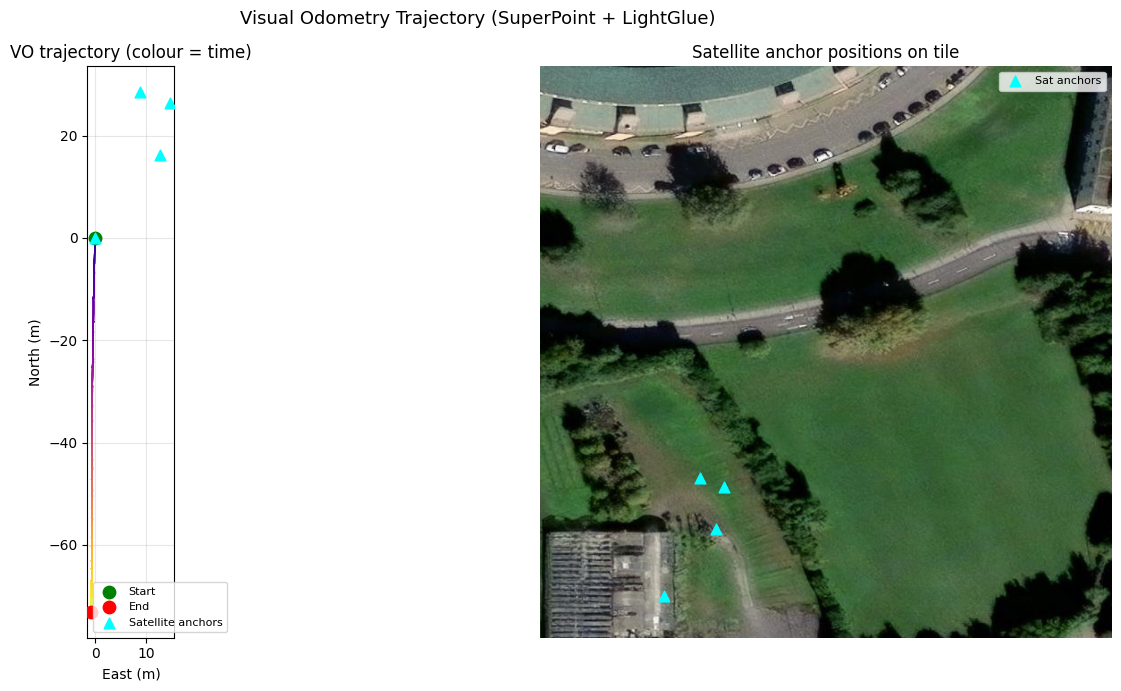

In [26]:
vo_east_m  = [ r['cum_x'] * scale_m_per_px for r in vo_records]
vo_north_m = [-r['cum_y'] * scale_m_per_px for r in vo_records]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
colors = cm.plasma(np.linspace(0, 1, len(vo_east_m)))
for i in range(len(vo_east_m)-1):
    ax.plot(vo_east_m[i:i+2], vo_north_m[i:i+2], color=colors[i], linewidth=1)
ax.scatter(vo_east_m[0],  vo_north_m[0],  c='green', s=80, zorder=5, label='Start')
ax.scatter(vo_east_m[-1], vo_north_m[-1], c='red',   s=80, zorder=5, label='End')
if anchors:
    a0 = anchors[0]
    anc_east  = [(a['est_lon'] - a0['est_lon']) * 111320 * math.cos(math.radians(LAT))
                 for a in anchors]
    anc_north = [(a['est_lat'] - a0['est_lat']) * 111320 for a in anchors]
    ax.scatter(anc_east, anc_north, c='cyan', s=60, zorder=6, marker='^', label='Satellite anchors')
ax.set_xlabel('East (m)')
ax.set_ylabel('North (m)')
ax.set_title('VO trajectory (colour = time)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
if sat_tile is not None and anchors:
    ax2.imshow(sat_tile)
    lat_min, lat_max, lon_min, lon_max = bbox_sat
    def gps_to_px(lat, lon):
        x = (lon - lon_min) / (lon_max - lon_min) * IMG_SIZE
        y = (lat_max - lat) / (lat_max - lat_min) * IMG_SIZE
        return x, y
    anc_px = [gps_to_px(a['est_lat'], a['est_lon']) for a in anchors]
    ax2.scatter([p[0] for p in anc_px], [p[1] for p in anc_px],
                c='cyan', s=60, marker='^', zorder=5, label='Sat anchors')
    ax2.set_title('Satellite anchor positions on tile')
    ax2.axis('off')
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Satellite tile\nnot available',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Satellite overlay')

plt.suptitle('Visual Odometry Trajectory (SuperPoint + LightGlue)', fontsize=13)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11 — Fused Trajectory (VO + Satellite Anchors)

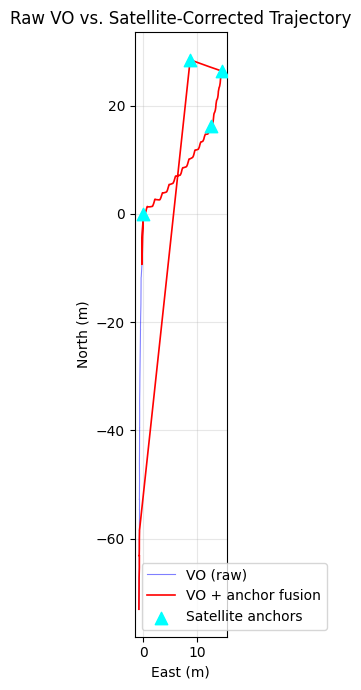

Blue = raw VO  |  Red = corrected by linearly interpolating anchor error


In [27]:
if len(anchors) < 2:
    print('Need >= 2 anchors for fusion -- skipping')
else:
    a0 = anchors[0]
    origin_lat, origin_lon = a0['est_lat'], a0['est_lon']

    def anchor_to_en(a):
        e = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))
        n = (a['est_lat'] - origin_lat) * 111320
        return e, n

    fused_east  = list(vo_east_m)
    fused_north = list(vo_north_m)

    for i in range(len(anchors) - 1):
        ai, aj = anchors[i], anchors[i+1]
        i0 = ai['vo_idx']
        i1 = aj['vo_idx']

        gps_e0, gps_n0 = anchor_to_en(ai)
        gps_e1, gps_n1 = anchor_to_en(aj)

        err_e0 = gps_e0 - vo_east_m[i0]
        err_n0 = gps_n0 - vo_north_m[i0]
        err_e1 = gps_e1 - vo_east_m[i1]
        err_n1 = gps_n1 - vo_north_m[i1]

        for j in range(i0, i1 + 1):
            t = (j - i0) / (i1 - i0) if i1 > i0 else 0
            fused_east[j]  = vo_east_m[j]  + err_e0 + t * (err_e1 - err_e0)
            fused_north[j] = vo_north_m[j] + err_n0 + t * (err_n1 - err_n0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot(vo_east_m, vo_north_m, 'b-', linewidth=0.8, alpha=0.5, label='VO (raw)')
    ax.plot(fused_east, fused_north, 'r-', linewidth=1.2, label='VO + anchor fusion')
    anc_e = [anchor_to_en(a)[0] for a in anchors]
    anc_n = [anchor_to_en(a)[1] for a in anchors]
    ax.scatter(anc_e, anc_n, c='cyan', s=80, zorder=5, marker='^', label='Satellite anchors')
    ax.set_xlabel('East (m)')
    ax.set_ylabel('North (m)')
    ax.set_title('Raw VO vs. Satellite-Corrected Trajectory')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'fused_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Blue = raw VO  |  Red = corrected by linearly interpolating anchor error')

---
## Cell 12 — Summary

In [28]:
total_frames  = len(frame_paths)
duration_s    = total_frames / 15.0
vo_frames     = len(vo_records)
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
failed_pairs  = sum(1 for r in inlier_ratios if r < 0.2)

print('== Deep Learning VO Summary (v2) ========================================')
print(f'Total frames:              {total_frames}  ({duration_s:.1f} s at 15 Hz)')
print(f'VO algorithm:              SuperPoint + LightGlue  '
      f'(max_kp={MAX_KP_VO}, {DOWNSAMPLE_SIZE[0]}x{DOWNSAMPLE_SIZE[1]})')
print(f'Satellite algorithm:       SuperPoint + LightGlue  '
      f'(max_kp={MAX_KP_SAT}, {SAT_MATCH_SIZE[0]}x{SAT_MATCH_SIZE[1]})')
print(f'Satellite source:          ESRI World Imagery (zoom {SAT_ZOOM})')
print(f'Device:                    {device}')
if timings_ms:
    mean_ms  = np.mean(timings_ms)
    live_str = 'live-ready' if mean_ms < 1000/15 else 'exceeds budget'
    print(f'Mean per-frame time:       {mean_ms:.1f} ms ({live_str} at 15 Hz)')
    print(f'Effective throughput:      {1000/mean_ms:.0f} fps capability')
if match_scores_vo:
    print(f'Mean LightGlue VO score:   {np.mean(match_scores_vo):.3f}')
print(f'Failed VO pairs (IR<0.2):  {failed_pairs} / {vo_frames-1}  '
      f'({100*failed_pairs/max(1,vo_frames-1):.1f}%)')
print(f'Mean inlier ratio:         {np.mean(inlier_ratios):.3f}')
print(f'Satellite anchors:         {len(anchors)}')
if anchors:
    print(f'Mean anchor inliers:       {np.mean([a["inliers"] for a in anchors]):.1f}')
    print(f'Mean anchor LG score:      {np.mean([a["mean_score"] for a in anchors]):.3f}')
    print(f'Mean dist from nominal:    {np.mean([a["dist_nominal_m"] for a in anchors]):.0f} m')
if drift_records:
    print(f'Final drift:               {drift_records[-1]["drift_m"]:.1f} m '
          f'after {drift_records[-1]["time_s"]:.1f} s')
    print(f'Drift rate:                '
          f'{drift_records[-1]["drift_m"]/drift_records[-1]["time_s"]:.2f} m/s')
print('==========================================================================')

== Deep Learning VO Summary (v2) ========================================
Total frames:              3430  (228.7 s at 15 Hz)
VO algorithm:              SuperPoint + LightGlue  (max_kp=1024, 640x480)
Satellite algorithm:       SuperPoint + LightGlue  (max_kp=4096, 640x480)
Satellite source:          ESRI World Imagery (zoom 18)
Device:                    cuda
Mean per-frame time:       75.8 ms (exceeds budget at 15 Hz)
Effective throughput:      13 fps capability
Mean LightGlue VO score:   1.000
Failed VO pairs (IR<0.2):  0 / 3429  (0.0%)
Mean inlier ratio:         0.997
Satellite anchors:         4
Mean anchor inliers:       8.2
Mean anchor LG score:      1.000
Mean dist from nominal:    51 m
Final drift:               78.1 m after 181.0 s
Drift rate:                0.43 m/s


---
## Cell 13 — Save Results Log

In [29]:
import csv, json, datetime

run_ts  = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = RESULTS_DIR

vo_log_path = log_dir / f'dl_vo_log_{run_ts}.csv'
vo_fields = ['frame_idx', 'cum_x', 'cum_y', 'cum_yaw',
             'dx', 'dy', 'dyaw', 'good_matches', 'inliers', 'inlier_ratio', 'mean_score']
with open(vo_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=vo_fields)
    w.writeheader()
    for r in vo_records:
        w.writerow({k: r[k] for k in vo_fields})
print(f'VO log:      {vo_log_path}  ({len(vo_records)} rows)')

anc_log_path = log_dir / f'dl_anchors_log_{run_ts}.csv'
anc_fields = ['frame_idx', 'vo_idx', 'est_lat', 'est_lon',
              'good_matches', 'inliers', 'mean_score', 'dist_nominal_m']
with open(anc_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=anc_fields)
    w.writeheader()
    for a in anchors:
        w.writerow({k: a.get(k) for k in anc_fields})
print(f'Anchors log: {anc_log_path}  ({len(anchors)} rows)')

summary = {
    'run_timestamp':      run_ts,
    'notebook':           'deep_learning_localization_v2',
    'vo_model':           'SuperPoint',
    'matching_model':     'LightGlue',
    'satellite_source':   'ESRI_World_Imagery',
    'device':             str(device),
    'max_kp_vo':          MAX_KP_VO,
    'max_kp_sat':         MAX_KP_SAT,
    'sat_match_size':     SAT_MATCH_SIZE,
    'min_sat_inliers':    MIN_SAT_INLIERS,
    'total_frames':       len(frame_paths),
    'duration_s':         len(frame_paths) / 15.0,
    'sat_zoom':           SAT_ZOOM,
    'mean_frame_ms':      float(np.mean(timings_ms)) if timings_ms else None,
    'mean_lg_score_vo':   float(np.mean(match_scores_vo)) if match_scores_vo else None,
    'failed_vo_pairs':    int(sum(r['inlier_ratio'] < 0.2 for r in vo_records[1:])),
    'mean_inlier_ratio':  float(np.mean([r['inlier_ratio'] for r in vo_records[1:]])),
    'satellite_anchors':  len(anchors),
    'mean_anchor_inliers': float(np.mean([a['inliers'] for a in anchors])) if anchors else None,
    'scale_m_per_px':     scale_m_per_px,
    'final_drift_m':      drift_records[-1]['drift_m'] if drift_records else None,
    'plots_saved':        [str(p.name) for p in RESULTS_DIR.glob('*.png')],
}

summary_path = log_dir / f'dl_summary_{run_ts}.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary:     {summary_path}')
print()
for k, v in summary.items():
    if v is not None:
        print(f'  {k:<32} {v}')

VO log:      /content/results/nb3v2/dl_vo_log_20260623_093744.csv  (3430 rows)
Anchors log: /content/results/nb3v2/dl_anchors_log_20260623_093744.csv  (4 rows)
Summary:     /content/results/nb3v2/dl_summary_20260623_093744.json

  run_timestamp                    20260623_093744
  notebook                         deep_learning_localization_v2
  vo_model                         SuperPoint
  matching_model                   LightGlue
  satellite_source                 ESRI_World_Imagery
  device                           cuda
  max_kp_vo                        1024
  max_kp_sat                       4096
  sat_match_size                   (640, 480)
  min_sat_inliers                  8
  total_frames                     3430
  duration_s                       228.66666666666666
  sat_zoom                         18
  mean_frame_ms                    75.81606789471952
  mean_lg_score_vo                 1.0
  failed_vo_pairs                  0
  mean_inlier_ratio                0.997189423

---
## Cell 14 — Visual Verification

For 6 evenly-spaced anchors, shows:
- **Left**: drone camera frame
- **Middle**: ESRI satellite tile with estimated drone position marked (red crosshair)
- **Right**: fresh ESRI tile fetched and centred at the estimated GPS — terrain visible in the drone frame should match what's in the centre of this tile

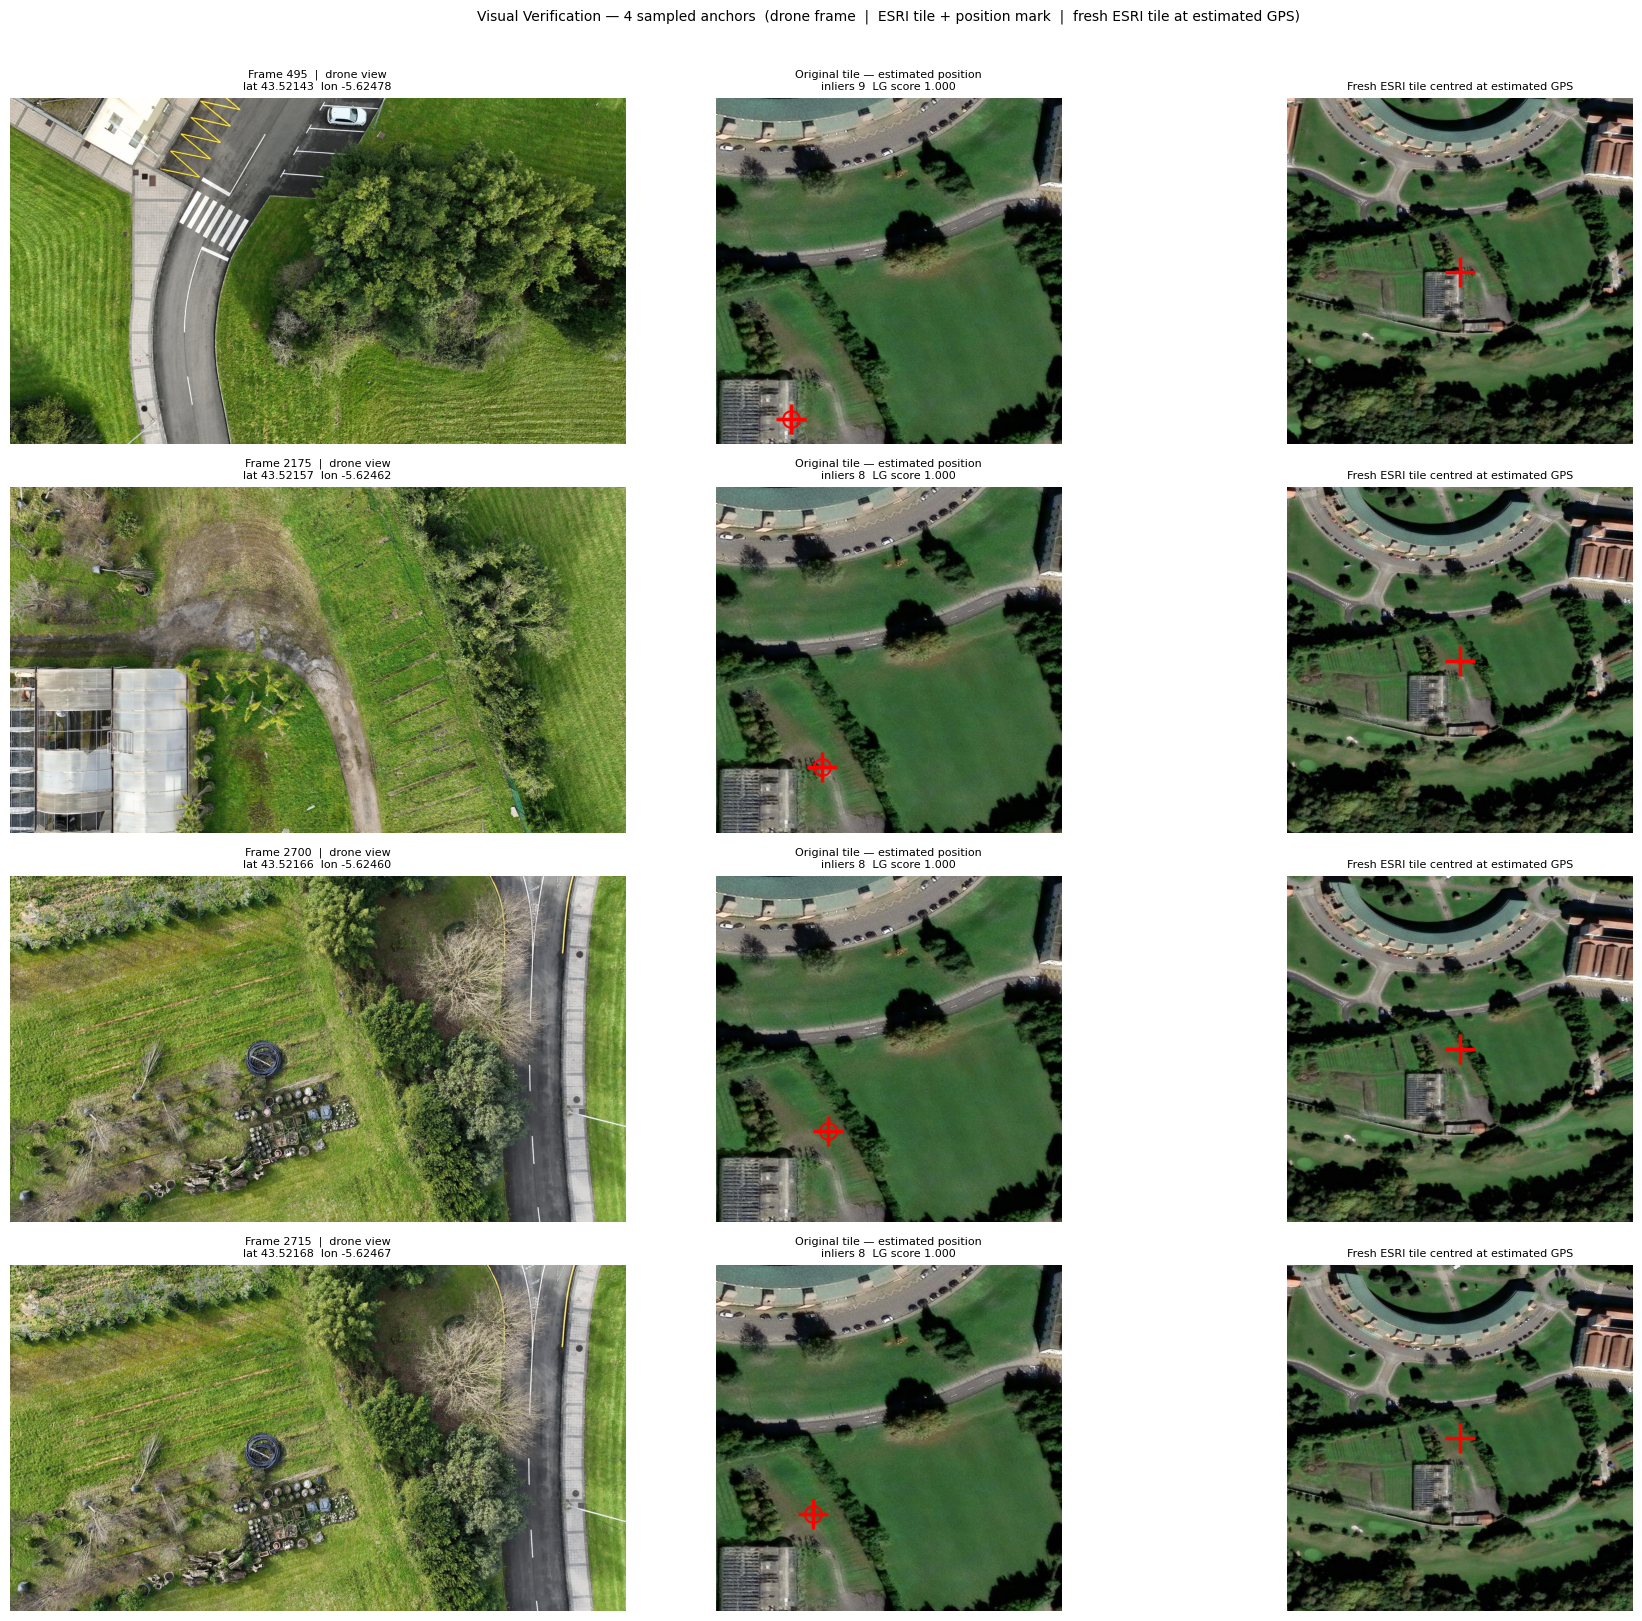

Saved: /content/results/nb3v2/visual_verification.png


In [30]:
N_VERIFY = 6

if not anchors:
    print('No anchors to visualise.')
elif sat_tile is None:
    print('No satellite tile loaded — run Cell 6 first.')
else:
    idxs   = np.linspace(0, len(anchors) - 1, min(N_VERIFY, len(anchors)), dtype=int)
    sample = [anchors[i] for i in idxs]

    lat_min, lat_max, lon_min, lon_max = bbox_sat
    tile_h, tile_w = sat_tile.shape[:2]

    def _gps_to_sat_px(lat, lon):
        x = (lon - lon_min) / (lon_max - lon_min) * tile_w
        y = (lat_max - lat) / (lat_max - lat_min) * tile_h
        return x, y

    fig, axes = plt.subplots(len(sample), 3, figsize=(18, 4 * len(sample)))
    if len(sample) == 1:
        axes = [axes]

    for row, anchor in enumerate(sample):
        est_lat = anchor['est_lat']
        est_lon = anchor['est_lon']

        drone_rgb = cv2.cvtColor(cv2.imread(str(frame_paths[anchor['frame_idx']])),
                                  cv2.COLOR_BGR2RGB)
        axes[row][0].imshow(drone_rgb)
        axes[row][0].set_title(
            f'Frame {anchor["frame_idx"]}  |  drone view\n'
            f'lat {est_lat:.5f}  lon {est_lon:.5f}', fontsize=8)
        axes[row][0].axis('off')

        px, py = _gps_to_sat_px(est_lat, est_lon)
        axes[row][1].imshow(sat_tile)
        axes[row][1].plot(px, py, 'r+', markersize=22, markeredgewidth=2.5)
        axes[row][1].plot(px, py, 'ro', markersize=12, fillstyle='none', markeredgewidth=1.5)
        axes[row][1].set_title(
            f'Original tile — estimated position\n'
            f'inliers {anchor["inliers"]}  LG score {anchor.get("mean_score", 0):.3f}', fontsize=8)
        axes[row][1].axis('off')

        fname = DATA_DIR / f'sat_verify_{est_lat:.5f}_{est_lon:.5f}_z{SAT_ZOOM}.png'
        fresh = None
        if fname.exists():
            fresh = np.array(Image.open(fname).convert('RGB'))
        else:
            try:
                fresh = fetch_esri_tile(est_lat, est_lon, IMG_SIZE, SAT_ZOOM)
                Image.fromarray(fresh).save(fname)
            except Exception as e:
                print(f'  ESRI tile fetch failed (frame {anchor["frame_idx"]}): {e}')

        if fresh is not None:
            cx, cy = fresh.shape[1] / 2, fresh.shape[0] / 2
            axes[row][2].imshow(fresh)
            axes[row][2].plot(cx, cy, 'r+', markersize=22, markeredgewidth=2.5)
            axes[row][2].set_title('Fresh ESRI tile centred at estimated GPS', fontsize=8)
        else:
            axes[row][2].text(0.5, 0.5, 'Fetch failed', ha='center', va='center',
                              transform=axes[row][2].transAxes, fontsize=10)
        axes[row][2].axis('off')

    plt.suptitle(
        f'Visual Verification — {len(sample)} sampled anchors  '
        '(drone frame  |  ESRI tile + position mark  |  fresh ESRI tile at estimated GPS)',
        fontsize=10, y=1.01)
    plt.tight_layout()
    out_path = RESULTS_DIR / 'visual_verification.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')

In [31]:
import shutil, os

drive_results = '/content/drive/MyDrive/capstone-dronomy/results/nb3v2'
os.makedirs(drive_results, exist_ok=True)
shutil.copytree(str(RESULTS_DIR), drive_results, dirs_exist_ok=True)
print(f'Results saved to Drive: {drive_results}')
print(os.listdir(drive_results))


Results saved to Drive: /content/drive/MyDrive/capstone-dronomy/results/nb3v2
['dl_anchors_log_20260623_093744.csv', 'dl_vo_log_20260623_093744.csv', 'dl_summary_20260623_093744.json', 'trajectory.png', 'fused_trajectory.png', 'dl_vo_log_20260623_093123.csv', 'vo_displacement.png', 'dl_summary_20260623_093123.json', 'vo_inlier_metrics.png', 'dl_anchors_log_20260623_093123.csv', 'visual_verification.png']
